In [27]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.kasteleyn import kasteleyn_matrix, find_kasteleyn_number

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [28]:
def expand_edges_to_squares(lattice: Lattice, chosen_edges: np.ndarray) -> Lattice:
    """Expand a select number of edges into squares

    Args:
        lattice (Lattice): The starting lattice
        chosen_edges (np.ndarray): The edges to expand

    Returns:
        Lattice: The final lattice
    """

    ind_touched = lattice.edges.indices[chosen_edges].flatten()
    assert len(set(ind_touched)) == len(
        ind_touched
    ), "Edges to expand touch the same vertex"

    if len(chosen_edges) == 0:
        return lattice

    # make vertices into triangles
    l2 = gu.vertices_to_polygon(lattice, lattice.edges.indices[chosen_edges].flatten())

    pl.plot_edges(l2)
    plt.show()
    return 0

    # next add the right edges to have the squares present
    edges_to_add = copy(l2.edges.indices)
    crossing_to_add = copy(l2.edges.crossing)
    vertices_to_remove = []

    for chosen_edge in chosen_edges:
        adj_plaqs = l2.edges.adjacent_plaquettes[chosen_edge]
        vertices_to_remove.append(l2.edges.indices[chosen_edge])

        for p_index in adj_plaqs:
            plaquette = l2.plaquettes[p_index]

            e_in_loop = np.where(plaquette.edges == chosen_edge)[0]
            i_in_loop = np.array(
                [e_in_loop - 1, e_in_loop, e_in_loop + 1]
            ).flatten() % len(plaquette.edges)

            signs_in_run = plaquette.directions[i_in_loop]
            edges_in_run = plaquette.edges[i_in_loop]

            vertices_in_run = l2.edges.indices[edges_in_run]
            crossing_in_run = l2.edges.crossing[edges_in_run] * signs_in_run[:, None]

            cross = np.sum(crossing_in_run, axis=0)
            i = (1 - signs_in_run) // 2
            edge = np.array([vertices_in_run[0, i[0]], vertices_in_run[-1, 1 - i[0]]])

            edges_to_add = np.vstack([edges_to_add, edge])
            crossing_to_add = np.vstack([crossing_to_add, cross])

            # crossing_to_add.append(cross)

    l3 = Lattice(l2.vertices.positions, edges_to_add, crossing_to_add)
    l4 = gu.remove_vertices(l3, np.array(vertices_to_remove).flatten())

    return l4

In [29]:
ns = 15
lattice = eg.honeycomb_lattice(1)

Exception: Lattice has duplicate edges

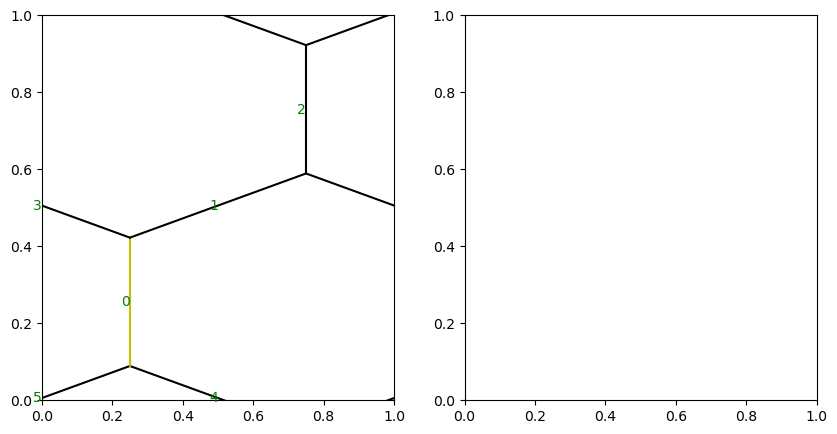

In [ ]:
from dimer_models.lattice_generation import expand_edges_to_squares


chosen_edges = [0]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
labels = np.array([0] * lattice.n_edges)
[labels.__setitem__(i, 1) for i in chosen_edges]

pl.plot_edges(lattice, labels, color_scheme=["k", "y"], ax=ax[0])
pl.plot_edge_indices(
    lattice,
    offset=0,
    ax=ax[0],
)


l2 = expand_edges_to_squares(lattice, chosen_edges)
pl.plot_edges(l2, ax=ax[1])
pl.plot_edge_indices(l2, offset=0, ax=ax[1])

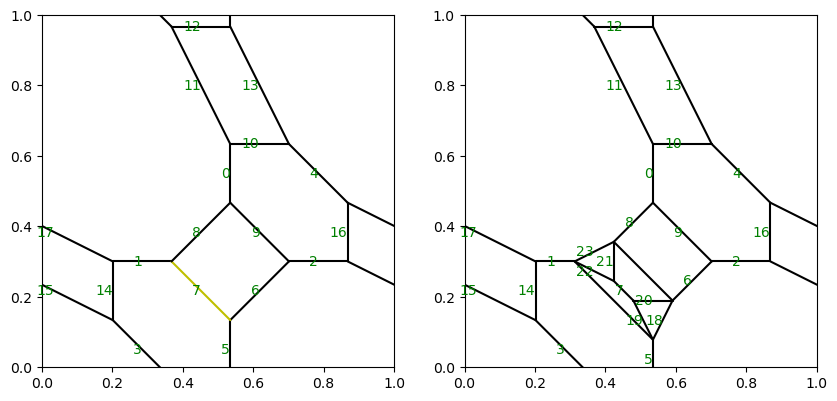

In [ ]:
chosen_edges = [7]
labels = np.array([0] * lattice.n_edges)
[labels.__setitem__(i, 1) for i in chosen_edges]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
[a.set_aspect("equal") for a in ax]
pl.plot_edges(lattice, labels=labels, color_scheme=["k", "y"], ax=ax[0])
pl.plot_edge_indices(lattice, offset=0, ax=ax[0])

l2 = gu.vertices_to_polygon(lattice, lattice.edges.indices[chosen_edges].flatten())


edges_to_add = []
crossing_to_add = []
for c_edge in chosen_edges:

    two_plaqs = lattice.edges.adjacent_plaquettes[
        c_edge
    ]  # plaquettes adjacent to the edge
    adj_edges = lattice.edges.adjacent_edges[
        c_edge
    ]  # edges adjacent to the original edge

    edge_pairs = [
        np.intersect1d(p.edges, adj_edges) for p in lattice.plaquettes[two_plaqs]
    ]

    for pair in edge_pairs:
        v = np.array([*pair, c_edge])
        all_adjacents = np.concatenate([l2.edges.adjacent_edges[i] for i in v])
        u, counts = np.unique(all_adjacents, return_counts=True)
        edges_to_combine = u[counts > 1]

        vertices_to_combine = l2.edges.indices[edges_to_combine]
        crossing_to_combine = l2.edges.crossing[edges_to_combine]

        nu_edge = copy(l2.edges.indices[c_edge])
        nu_cros = copy(l2.edges.crossing[c_edge])

        for j, v in enumerate(nu_edge):
            pos = np.array(np.where(vertices_to_combine == v)).flatten()
            nu_edge[j] = vertices_to_combine[pos[0], 1 - pos[1]]
            sign = -(1 ** (pos[1] == j))

            nu_cros += crossing_to_combine[pos[0]] * sign

        edges_to_add.append(nu_edge)
        crossing_to_add.append(nu_cros)

new_edges = np.concatenate([l2.edges.indices, edges_to_add])
new_crossing = np.concatenate([l2.edges.crossing, crossing_to_add])

l3 = Lattice(l2.vertices.positions, new_edges, new_crossing)


pl.plot_edges(l3, ax=ax[1])
pl.plot_edge_indices(l2, offset=0, ax=ax[1])